# <CENTER> **PROJECT: DL_CAPTCHA_NEW**

---

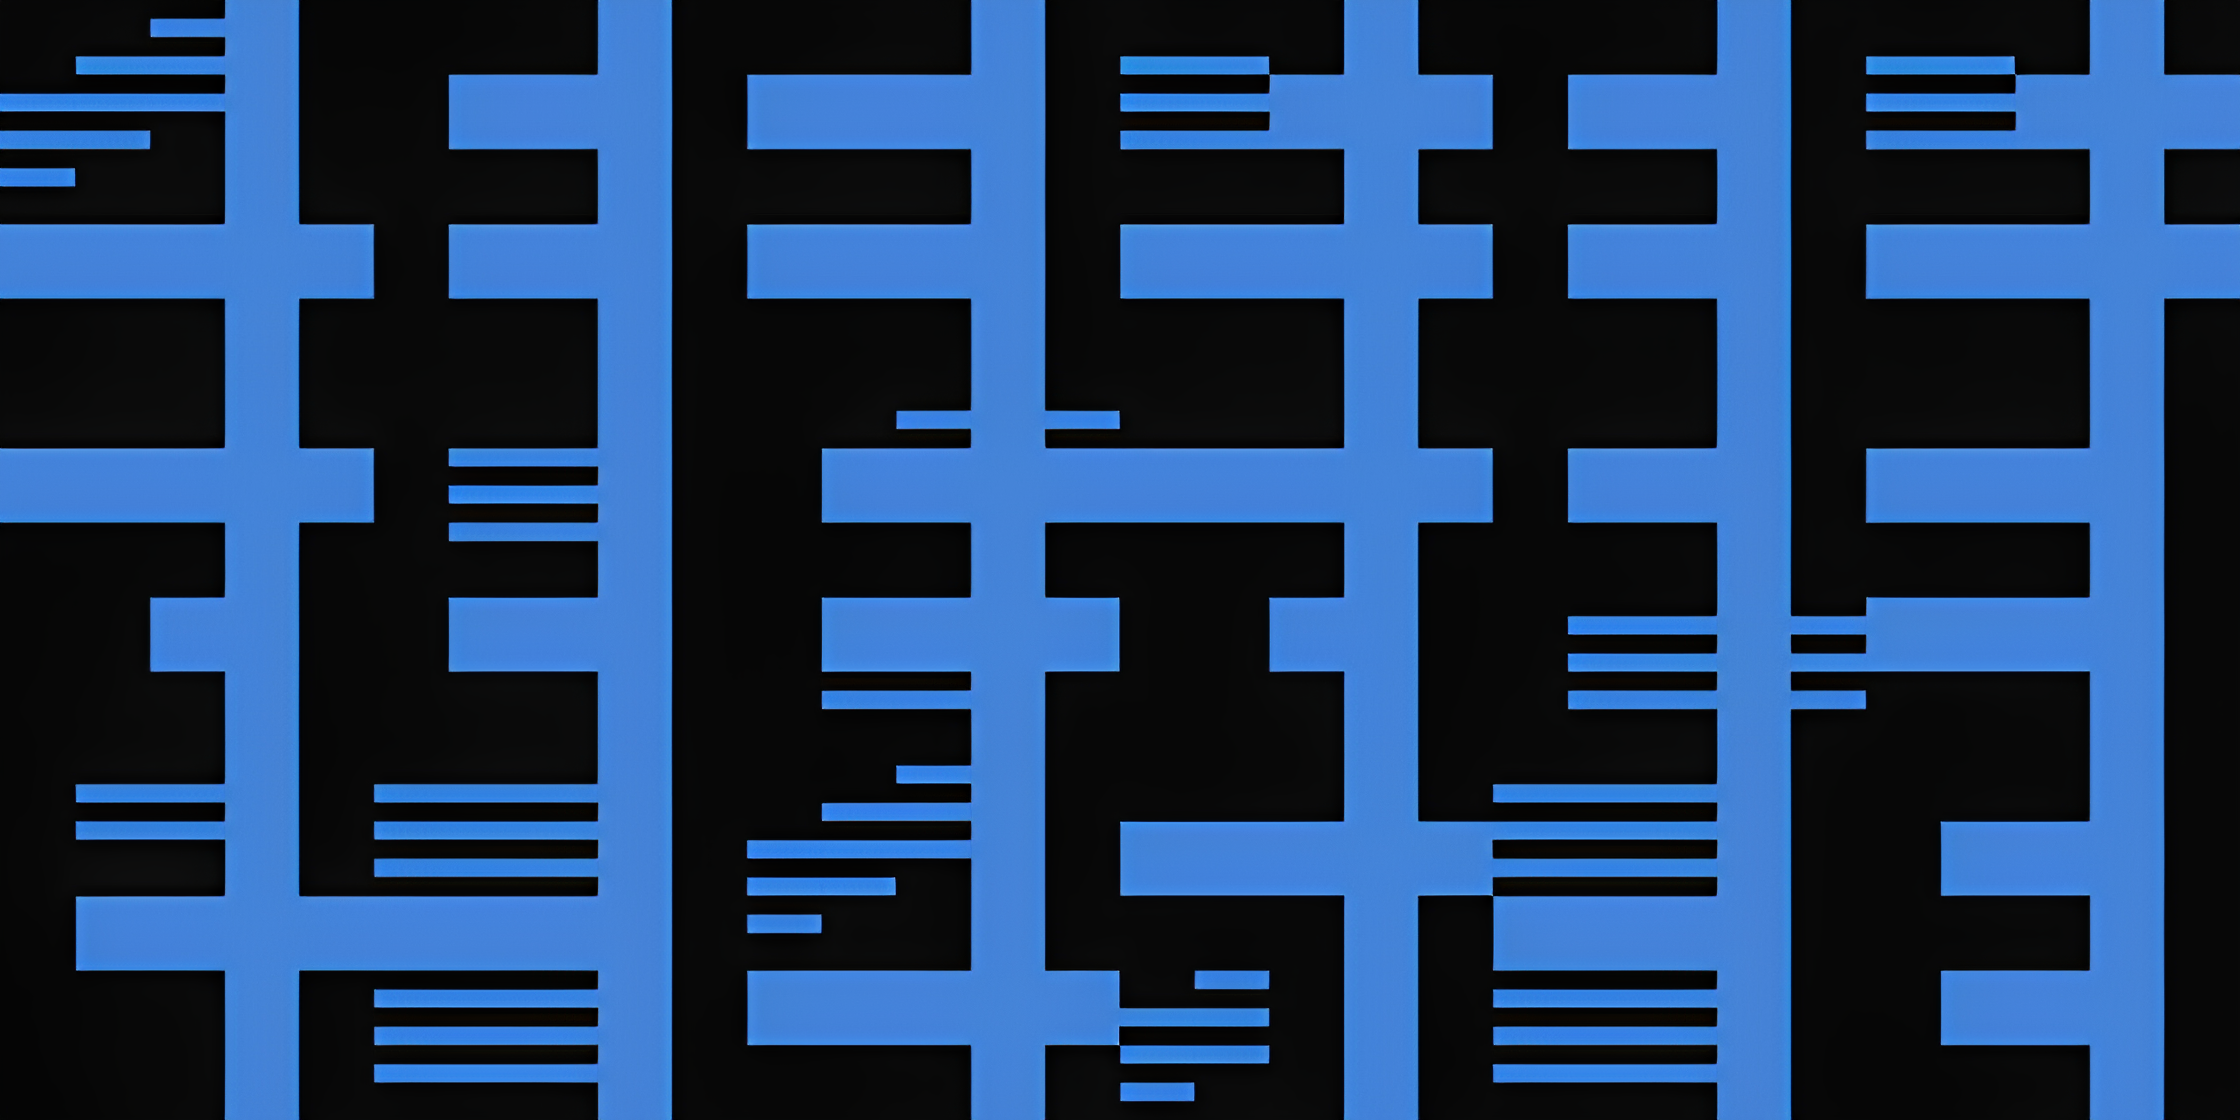

---

#### **Описание:**

В этом соревновании вам предлагается задача из области компьютерного зрения – распознавание букв английского алфавита на искаженных и зашумленных изображениях. Примеры:

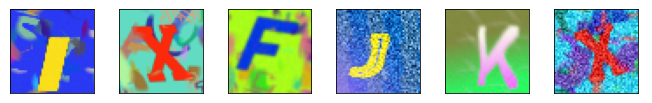

Всего доступно $20$ тысяч размеченных изображений размером $48$ x $48$ с $3$ цветовыми каналами (**RGB**), поэтому массив `images` имеет размер ($20000$, $48$, $48$, $3$). В массиве `labels` содержатся ответы к тренировочному набору изображений. В английском алфавите $26$ букв: $0$-й класс соответствует букве *А* и так далее по алфавиту, $25$-й класс — буква *Z*.

---

#### **Постановка задачи:**

В данном проекте необходимо обучить нейронную сеть и с ее помощью предсказать метки классов для изображений из файла `images_sub.npy`, в нем $50$ тысяч изображений.

---


#### **Основные цели:**

* Сформировать набор данных на основе предоставленных источников информации;

* Провести подготовку данных к обучению модели;

* Обучить нейронную сеть, классифицирующую метки классов для изображений.

---


#### **Этапы работы над проектом:**

Проект будет состоять из трёх частей:

`1.` *Базовый анализ и знакомство с данными*;

`2.` *Подготовка данных*;

`3.` *Machine Learning*.

---

**Импортируем необходимые библиотеки:**

In [176]:
# Для работы с данными
import pandas as pd
import numpy as np


# Для построения графиков
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


# Для построения модели
from sklearn import model_selection
from sklearn import metrics
import tensorflow as tf
from tensorflow.keras import layers, models, utils
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

**Загрузка данных:**

In [163]:
# Загружаем данные
images_data = np.load('data/images.npy')
labels_data = np.load('data/labels.npy')
images_sub_data = np.load('data/images_sub.npy')

=============================================================================================================================================

## <CENTER> **`1.` Базовый анализ и знакомство с данными**

На данном этапе изучим информацию предоставленных данных.

#### $1.1$

**Выведем информацию по таблицам.**

Создаём функцию:

In [164]:
# Создадим функцию для вывода информации по датасету
def check_data_inf(data, data_name = None, length1 = None, length2 = None):
    
    # Выводим размеры таблицы
    print(f'Данные таблицы "{data_name}" имеют следующую размерность:\n')
    print('Количество строк: {};\nКоличество признаков (столбцов): {}.'.format(data.shape[0], data.shape[1]))
    print('-' * length1)

    # Выведем первые пять строк 
    display(data)
    print('-' * length2)

Выводим результат:

In [165]:
# Выводим информацию по полученным таблицам при помощи функции 'check_data_inf'
check_data_inf(
    data = images_data,
    data_name = 'images_data',
    length1 = 40,
    length2 = 150
)
print('\n\n')

check_data_inf(
    data = images_sub_data,
    data_name = 'images_sub_data',
    length1 = 40,
    length2 = 150
)

Данные таблицы "images_data" имеют следующую размерность:

Количество строк: 20000;
Количество признаков (столбцов): 48.
----------------------------------------


array([[[[144, 109, 189],
         [153, 122, 179],
         [169, 143, 163],
         ...,
         [158, 130, 175],
         [149, 117, 183],
         [131,  91, 200]],

        [[128,  87, 203],
         [138, 101, 193],
         [160, 132, 172],
         ...,
         [158, 129, 175],
         [152, 121, 181],
         [132,  93, 199]],

        [[127,  86, 204],
         [135,  96, 197],
         [145, 111, 188],
         ...,
         [158, 129, 175],
         [152, 121, 181],
         [132,  93, 198]],

        ...,

        [[147, 115, 185],
         [159, 131, 174],
         [168, 142, 165],
         ...,
         [159, 130, 174],
         [154, 123, 179],
         [137, 100, 194]],

        [[130,  90, 201],
         [143, 108, 189],
         [165, 138, 168],
         ...,
         [159, 130, 175],
         [153, 122, 180],
         [131,  91, 200]],

        [[130,  90, 201],
         [138, 102, 194],
         [139, 102, 193],
         ...,
         [158, 129, 175],
        

------------------------------------------------------------------------------------------------------------------------------------------------------



Данные таблицы "images_sub_data" имеют следующую размерность:

Количество строк: 50000;
Количество признаков (столбцов): 48.
----------------------------------------


array([[[[ 76,   5,   3],
         [ 76,   5,   3],
         [ 76,   5,   3],
         ...,
         [ 76,   5,   3],
         [ 76,   5,   3],
         [ 76,   5,   3]],

        [[ 20, 172, 144],
         [ 20, 172, 144],
         [ 20, 172, 144],
         ...,
         [ 20, 172, 144],
         [ 20, 172, 144],
         [ 20, 172, 144]],

        [[ 76,   5,   3],
         [ 76,   5,   3],
         [ 76,   5,   3],
         ...,
         [ 76,   5,   3],
         [ 76,   5,   3],
         [ 76,   5,   3]],

        ...,

        [[ 20, 172, 144],
         [ 20, 172, 144],
         [ 20, 172, 144],
         ...,
         [ 20, 172, 144],
         [ 20, 172, 144],
         [ 20, 172, 144]],

        [[ 76,   5,   3],
         [ 76,   5,   3],
         [ 76,   5,   3],
         ...,
         [ 76,   5,   3],
         [ 76,   5,   3],
         [ 76,   5,   3]],

        [[ 20, 172, 144],
         [ 20, 172, 144],
         [ 20, 172, 144],
         ...,
         [ 20, 172, 144],
        

------------------------------------------------------------------------------------------------------------------------------------------------------


#### $1.2$

**Проверка распределения классов.**

Посмотрим на распределение классов, для этого построим график `barplot`:


Распределение классов в датасете:
------------------------------------------------------------------------------------------------------------------------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_15920\1294271435.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


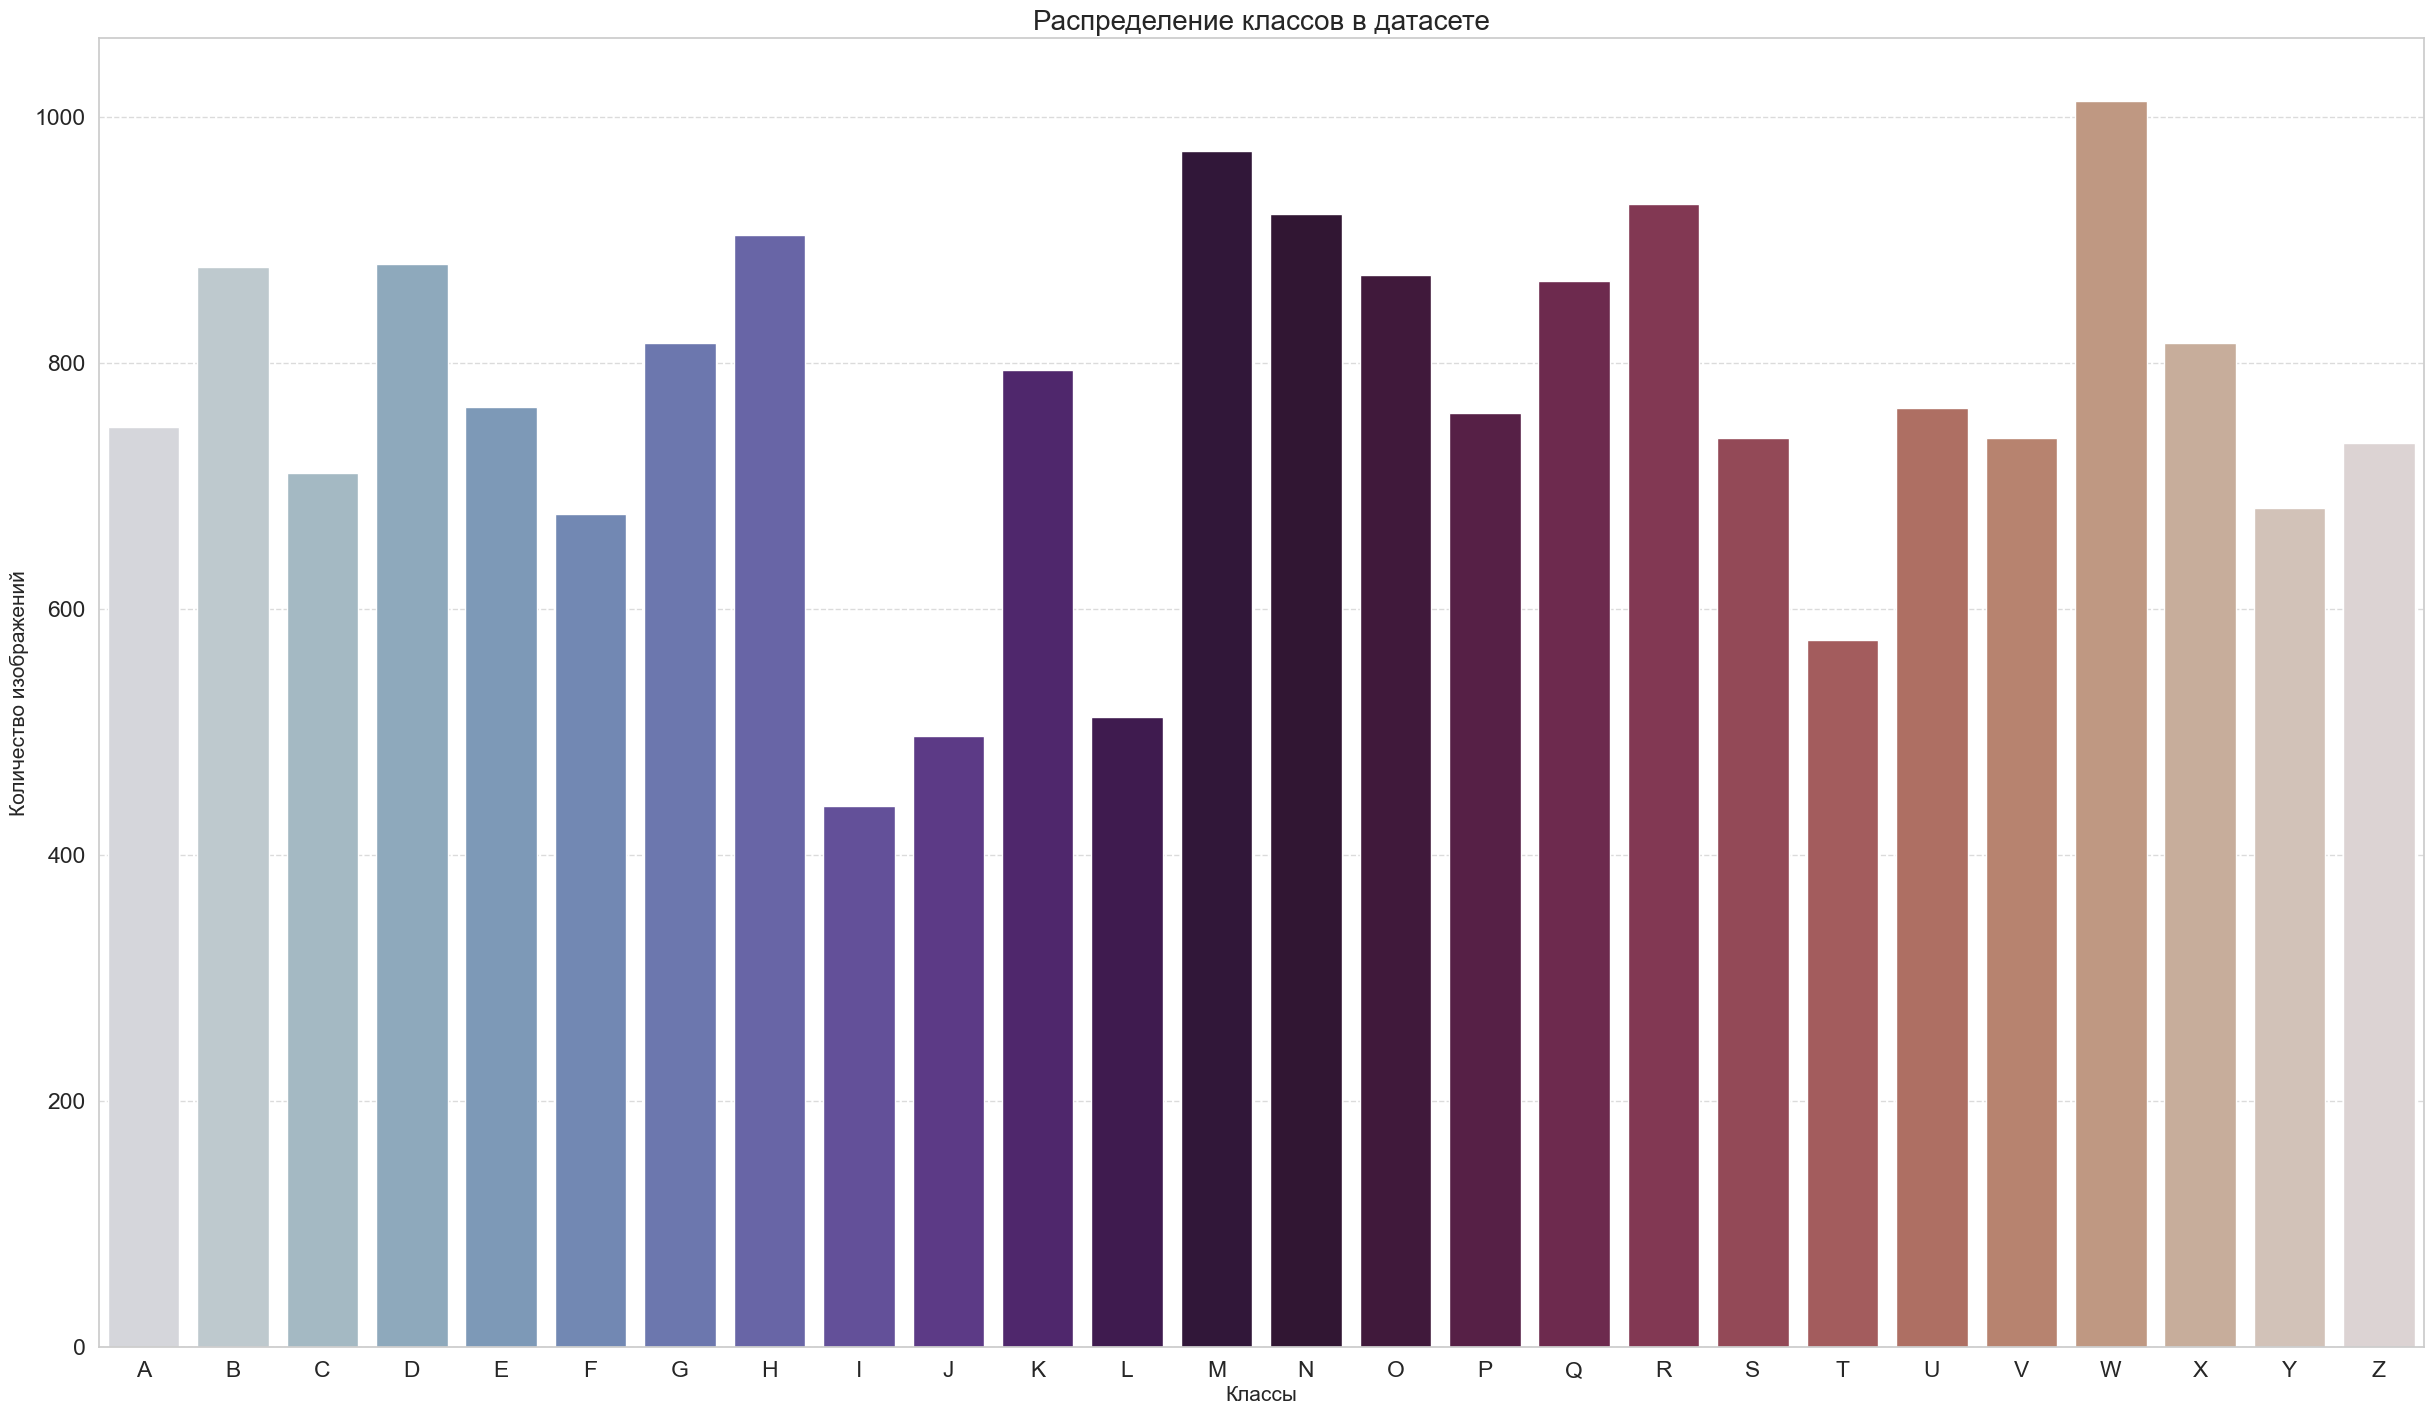

------------------------------------------------------------------------------------------------------------------------------------------------------


In [166]:
# Посмотрим на распределение классов, для этого построим график `barplot`
label_counts = pd.Series(labels_data).value_counts().sort_index()


# Задаём заголовок графика
print('\nРаспределение классов в датасете:')


# Настраиваем размер шрифта
sns.set_context('notebook', font_scale = 1.5)
print('-' * 150)


# Настраиваем размер графика
plt.figure(figsize = (30, 17))

# Устанавливаем стиль графика
sns.set(style = 'whitegrid', font_scale = 1.5)


# Строим график распределения классов
sns.barplot(
    x = [chr(ord('A') + i) for i in label_counts.index], 
    y = label_counts.values,
    palette = 'twilight'
)

# Настраиваем внешний вид графика
plt.title('Распределение классов в датасете', fontsize = 20)
plt.xlabel('Классы', fontsize =15)
plt.ylabel('Количество изображений', fontsize = 15)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)



# Отображаем график
plt.show()
print('-' * 150)

**Вывод:**

Исходя из полученной гистограммы можно заключить, что классы несбалансированы. Некоторые классы (например, буквы `G`, `J`, `K`, `M`, `N`, `P`, `Q`, `R`) имеют значительно больше примеров (около $800$-$1000$), тогда как другие (например, `X`, `Y`, `Z`) имеют заметно меньше (около $200$-$400$). Это говорит о сильном дисбалансе классов.

Для того, чтобы модель дала лучшие предсказания, необходима балансировка классов.

#### $1.3$

**Проверка изображений.**

Создадим функцию для вывода изображений букв:

In [167]:
# Создаём функцию для визуализации букв
def visualize_letters(images, labels, figsize, letters_num = 16):
    
    """
    Функция для визуализации букв из изображений.
    
    :param images: Список изображений.
    :param labels: Список меток для изображений.
    :param figsize: Размер фигуры для отображения.
    :param letters_num: Количество букв для отображения (по умолчанию 16).
    
    """
    
    # Проверяем входные параметры
    if not isinstance(images, (list, np.ndarray)):
        raise TypeError("Изображения должны быть списком или массивом numpy.")
    if len(images) != len(labels):
        raise ValueError("Количество изображений и меток должно совпадать.")
    if letters_num > len(images):
        raise ValueError("Количество букв для отображения не может превышать количество изображений.")
    
    
    # Задаём заглавие для графика
    print('\nВизуализация букв из изображений:\n')
    print(f'Количество изображений: {len(images)}')
    print(f'Количество меток: {len(labels)}')
    print(f'Количество букв для отображения: {letters_num}')
    print(f'Количество столбцов: {4}')
    print(f'Количество строк: {4}')
    print(f'Размер фигуры: {figsize}')
    print('-' * 150)
    
    
    # Настраиваем размер фигуры
    plt.figure(figsize = figsize)
    
    # Отображаем изображения с метками
    for i in range(letters_num):
        idx = np.random.randint(0, len(images))
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[idx])
        label = chr(65 + labels[idx])
        plt.title(f'Буква на изображении: {label}', fontsize = 12)
        plt.axis('off')
        
    # Настраиваем отображение
    plt.suptitle('Примеры букв из изображений', fontsize=16)
    plt.subplots_adjust(top=0.9, hspace=0.3, wspace=0.3)
    plt.tight_layout()
    
    
    # Показываем график
    plt.show()
    print('-' * 150)

Выводим изображения:


Визуализация букв из изображений:

Количество изображений: 20000
Количество меток: 20000
Количество букв для отображения: 16
Количество столбцов: 4
Количество строк: 4
Размер фигуры: (10, 10)
------------------------------------------------------------------------------------------------------------------------------------------------------


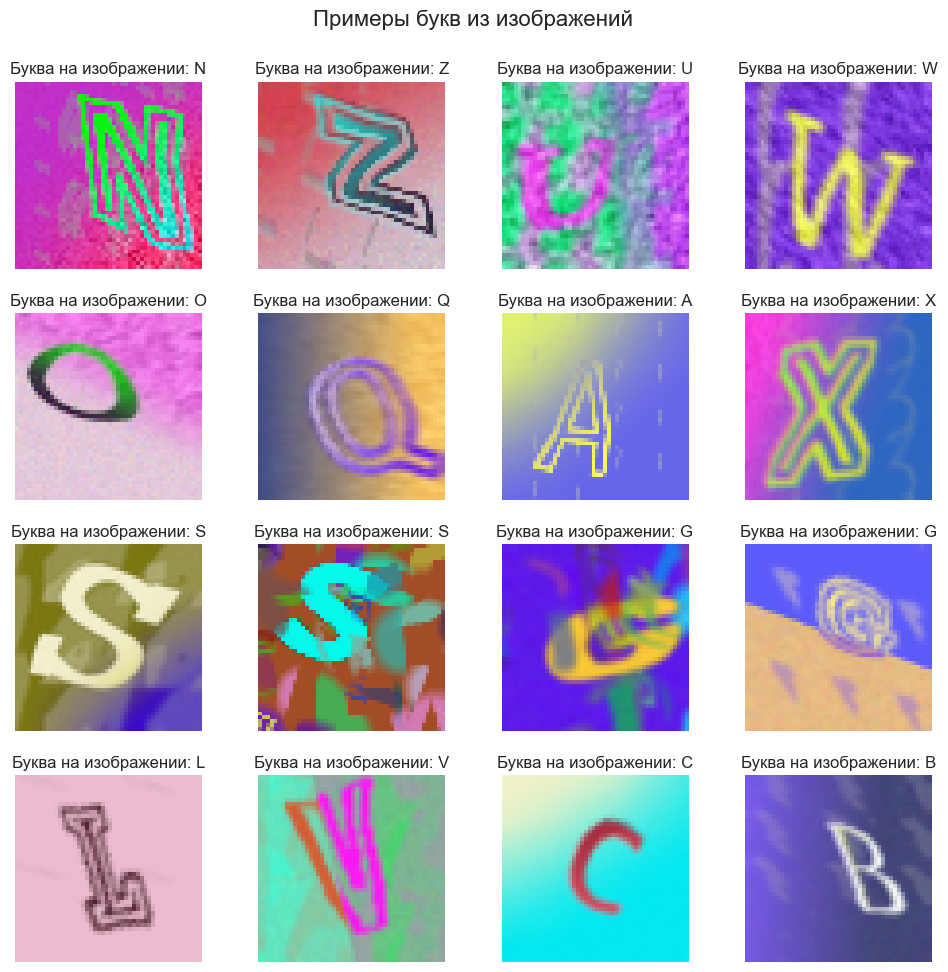

------------------------------------------------------------------------------------------------------------------------------------------------------


In [168]:
# Визуализируем буквы из изображений
visualize_letters(
    images = images_data,
    labels = labels_data,
    figsize = (10, 10) 
)

=============================================================================================================================================

## <CENTER> **`2.` Подготовка данных**

На данном этапе произведём преобразование и разделение данных.

#### $2.1$

Произведём нормализацию и преобразование данных:

In [169]:
# Данные делим на 255, чтобы значения пикселей были в диапазоне [0, 1]
images_data = images_data.astype('float32') / 255.0
images_sub_data = images_sub_data.astype('float32') / 255.0


# Преобразуем вектор правильных ответов при помощи метода 'to_categorical'
labels_data = utils.to_categorical(labels_data, num_classes = 26)

#### $2.2$

Теперь разделим тренировочную выборку на тренировочную и валидационную в соотношении $80$/$20$: 

In [170]:
# Разделение на обучающую и валидационную выборки
X_train, X_valid, y_train, y_valid = model_selection.train_test_split(
    images_data, labels_data,
    test_size = 0.2,
    random_state = 42
)



# Выводим размерности
print('Размер тренировочной выборки: {}'.format(X_train.shape))
print('Размер тестовой выборки: {}'.format(X_valid.shape))

Размер тренировочной выборки: (16000, 48, 48, 3)
Размер тестовой выборки: (4000, 48, 48, 3)


#### $2.3$

Проведём аугментацию данных:

In [171]:
# Аугментация данных
datagen = ImageDataGenerator(
    rotation_range = 10,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    fill_mode = 'nearest'
)


# Подгоняем генератор под тренировочные данные
# Это необходимо для того, чтобы генератор мог применять аугментацию к данным
datagen.fit(X_train)

=============================================================================================================================================

## <CENTER> **`3.` Machine Learning**

На данном этапе построим модель глубокого обучения, классифицирующую изображения с одеждой.

#### $3.1$

Строим модель свёрточной нейронной сети:

In [172]:
# Построение модели CNN
CNN_model = tf.keras.models.Sequential(
    
    [
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
    
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
    
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
    
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(26, activation='softmax')
    ]
    
)


# Компиляция модели
CNN_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)


# Вывод структуры модели
CNN_model.summary()

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 988,122 (3.77 MB)

 Trainable params: 986,650 (3.76 MB)

 Non-trainable params: 1,472 (5.75 KB)

#### $3.2$

Балансируем классы:

In [175]:
# Вычисление весов для классов
class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(np.argmax(labels_data, axis = 1)),
    y = np.argmax(labels_data, axis = 1)
)


# Преобразование в словарь
class_weights_dict = dict(enumerate(class_weights))


# Выводим веса классов
print(f'Веса классов: {class_weights_dict}')

Веса классов: {0: 1.0283833813245578, 1: 0.8761170492377782, 2: 1.0834236186348862, 3: 0.8741258741258742, 4: 1.0068465565847764, 5: 1.1362345188046812, 6: 0.942684766214178, 7: 0.8509189925119128, 8: 1.7482517482517483, 9: 1.547748026621266, 10: 0.968804495252858, 11: 1.5024038461538463, 12: 0.7913896802785692, 13: 0.8352125615969265, 14: 0.8831581736288969, 15: 1.0134792743488397, 16: 0.8882572392965002, 17: 0.8280202036929701, 18: 1.0409076714895389, 19: 1.3377926421404682, 20: 1.0081661457808246, 21: 1.0409076714895389, 22: 0.7593591009188245, 23: 0.942684766214178, 24: 1.1279043537108053, 25: 1.0465724751439036}


#### $3.3$

Обучаем модель:

In [177]:
# Колбэк для ранней остановки
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = 'valid_accuracy',
    mode = 'max',
    patience = 5,
    restore_best_weights = True
)


# Обучение модели с использованием аугментации данных
history = CNN_model.fit(
    datagen.flow(X_train, y_train, batch_size = 64),
    epochs = 50,
    validation_data = (X_valid, y_valid),
    class_weight = class_weights_dict,
    callbacks = [early_stopping]
)


# Оценка модели на валидационной выборке
valid_loss, valid_accuracy = CNN_model.evaluate(X_valid, y_valid)
print(f'Validation accuracy after augmentation: {valid_accuracy:.4f}')

Epoch 1/50


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 144ms/step - accuracy: 0.0470 - loss: 4.1729 - val_accuracy: 0.0243 - val_loss: 3.8608
Epoch 2/50
  1/250 ━━━━━━━━━━━━━━━━━━━━ 47s 189ms/step - accuracy: 0.1250 - loss: 3.2358

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `valid_accuracy` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 157ms/step - accuracy: 0.1347 - loss: 3.1480 - val_accuracy: 0.2785 - val_loss: 2.3758
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 177ms/step - accuracy: 0.3461 - loss: 2.1148 - val_accuracy: 0.4882 - val_loss: 1.6002
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 165ms/step - accuracy: 0.5017 - loss: 1.5773 - val_accuracy: 0.6145 - val_loss: 1.2052
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 165ms/step - accuracy: 0.5938 - loss: 1.2767 - val_accuracy: 0.6998 - val_loss: 0.9371
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.6510 - loss: 1.1089 - val_accuracy: 0.7185 - val_loss: 0.8524
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 165ms/step - accuracy: 0.6990 - loss: 0.9654 - val_accuracy: 0.7520 - val_loss: 0.7888
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 165ms/step - accuracy: 0.7191 - loss: 0.8896 - val_accuracy: 0.7837 - val_loss: 0.6908
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 169ms/step - accuracy: 0.7482 - loss: 0.7990 - val

Строим визуализацию:


Визуализация процесса обучения:
------------------------------------------------------------------------------------------------------------------------------------------------------


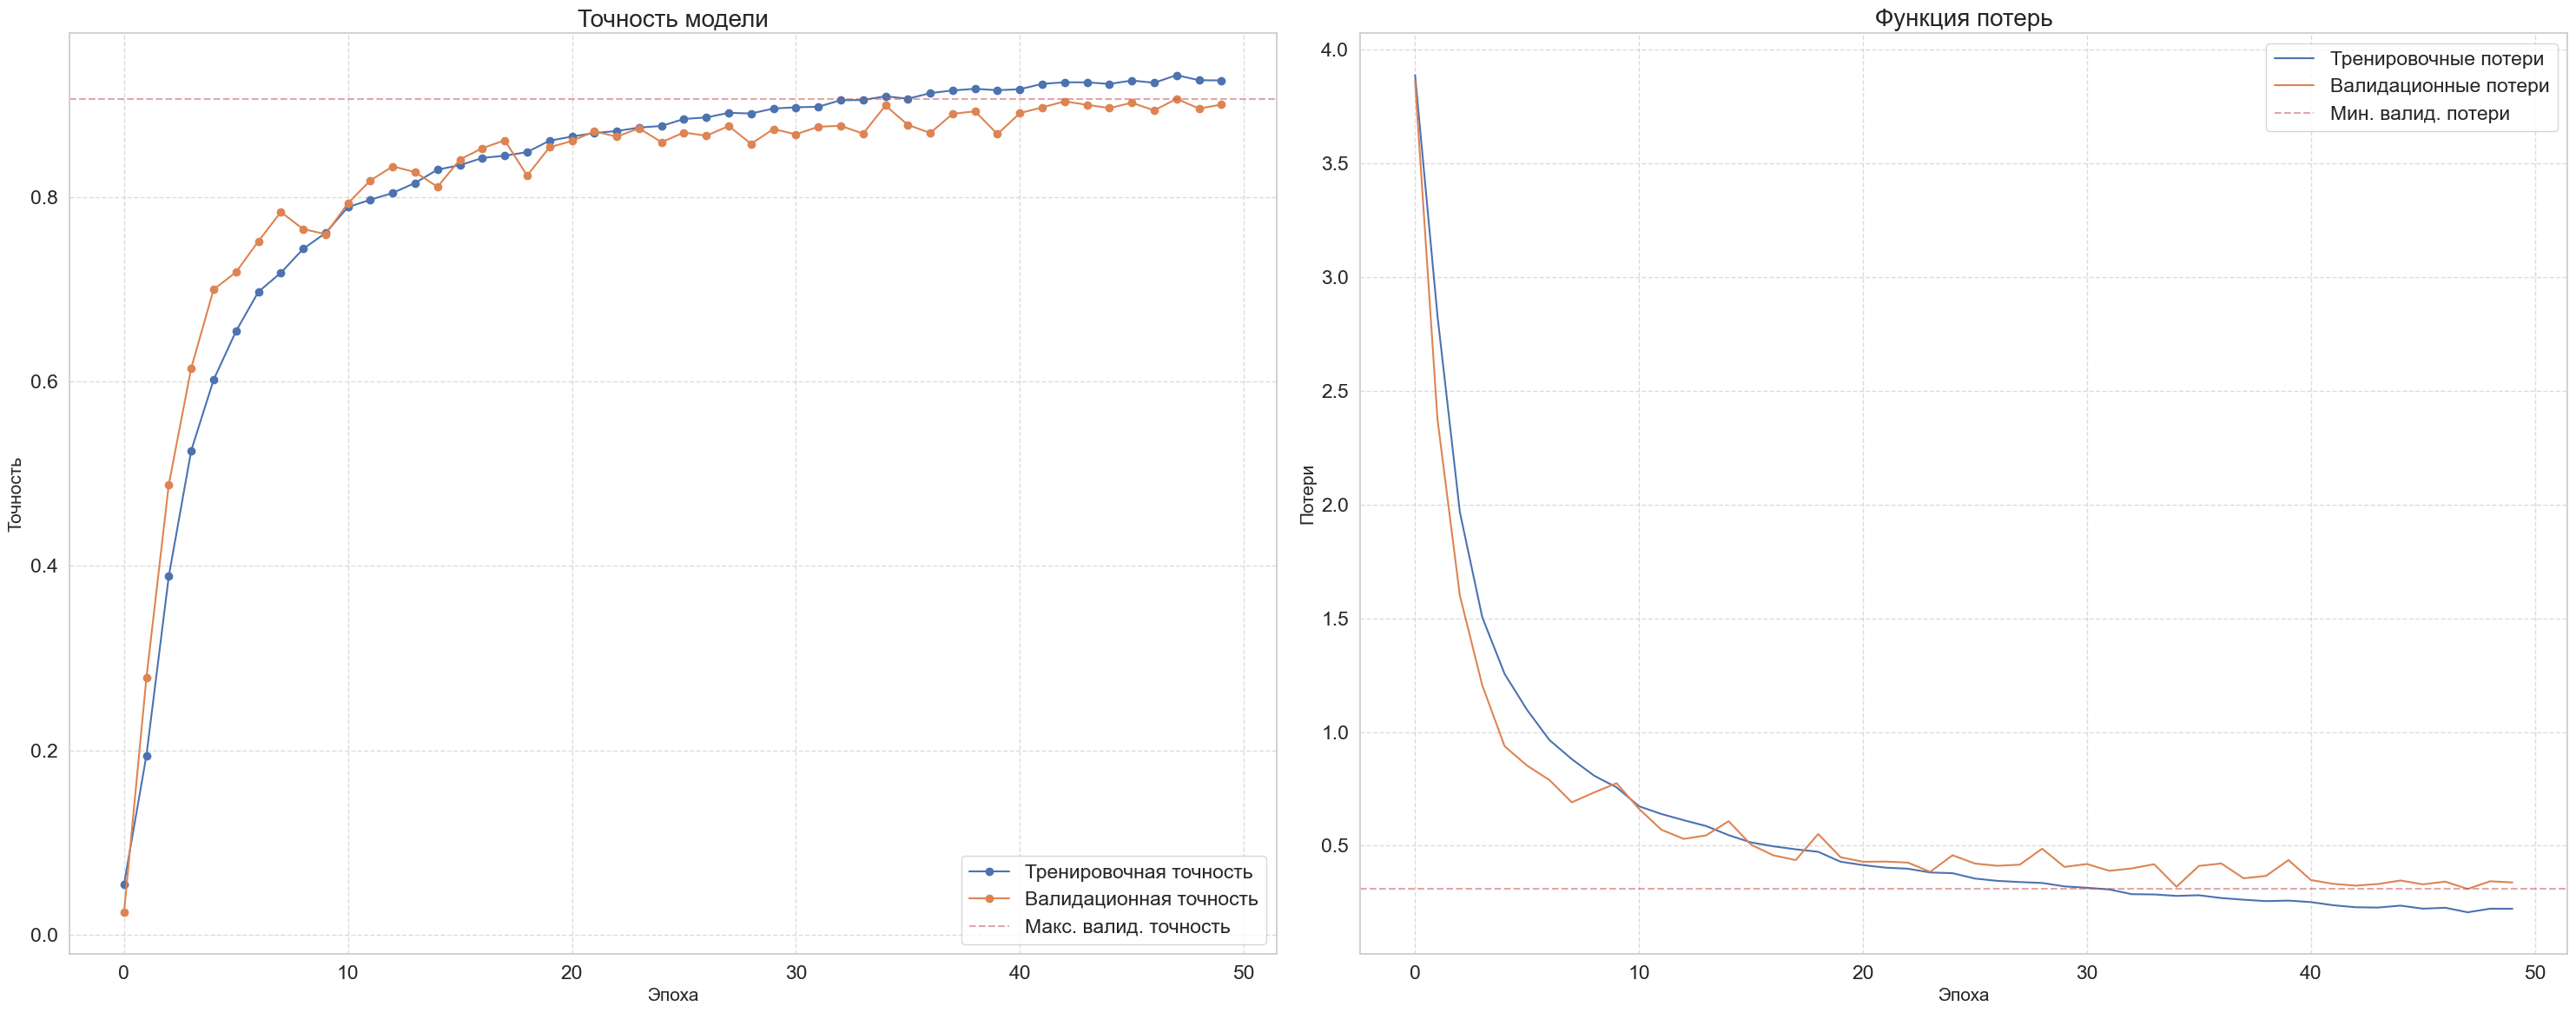

------------------------------------------------------------------------------------------------------------------------------------------------------


In [188]:
# Заглавие графика
print('\nВизуализация процесса обучения:')
print('-' * 150)



# Задаём размер графика
plt.figure(figsize = (30, 12))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label = 'Тренировочная точность', marker = 'o')
plt.plot(history.history['val_accuracy'], label = 'Валидационная точность', marker = 'o')
plt.axhline(y=max(history.history['val_accuracy']), color='r', linestyle='--', alpha=0.5, label='Макс. валид. точность')
plt.title('Точность модели', fontsize = 20)
plt.xlabel('Эпоха', fontsize = 15)
plt.ylabel('Точность', fontsize = 15)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.legend()
 
# График функции потерь
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label = 'Тренировочные потери')
plt.plot(history.history['val_loss'], label = 'Валидационные потери')
plt.axhline(y=min(history.history['val_loss']), color='r', linestyle='--', alpha=0.5, label='Мин. валид. потери')
plt.title('Функция потерь', fontsize = 20)
plt.xlabel('Эпоха', fontsize = 15)
plt.ylabel('Потери', fontsize = 15)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.legend()



# Выводим график
plt.show()
print('-' * 150)

**Вывод:**

Точность на обучающей выборке и валидационной выборке увеличивается с ростом числа эпох и стабилизируется на уровне около $0.8$-$0.85$ после $20$-$30$ эпох. Это указывает на хорошую обучаемость модели, но с признаками возможного переобучения, так как разрыв между обучающей и валидационной точностью немного увеличивается к $50$ эпохе.

#### $3.4$

Получение предсказаний:

In [179]:
# Производим предсказание на тестовой выборке
predictions = CNN_model.predict(images_sub_data)
predicted_classes = np.argmax(predictions, axis = 1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step


Строим визуализацию:


Визуализация букв из изображений:

Количество изображений: 50000
Количество меток: 50000
Количество букв для отображения: 16
Количество столбцов: 4
Количество строк: 4
Размер фигуры: (10, 10)
------------------------------------------------------------------------------------------------------------------------------------------------------


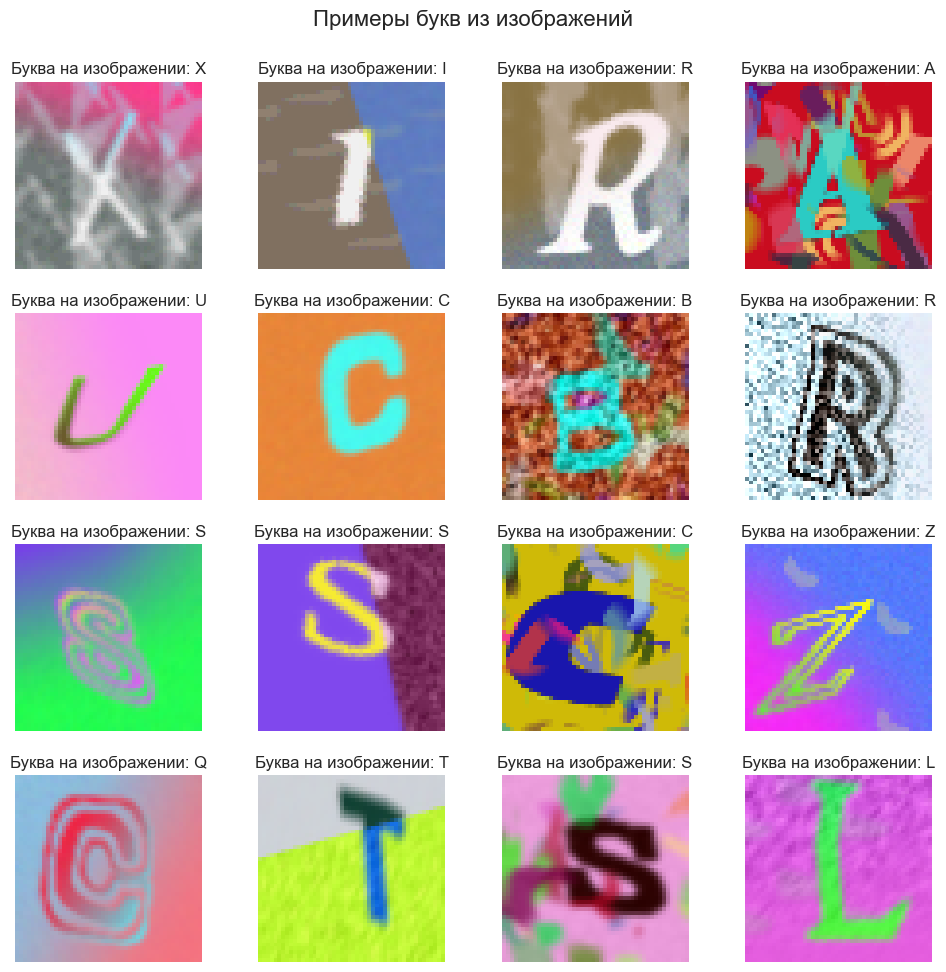

------------------------------------------------------------------------------------------------------------------------------------------------------


In [180]:
# Визуализация предсказанных букв на тестовых изображениях
visualize_letters(
    images = images_sub_data,
    labels = predicted_classes,
    figsize = (10, 10) 
)

**Вывод:**

В практически во всех случаях модель верно предсказала буквы на изображениях.

#### $3.5$

Используем валидационную выборку для оценки точности. Построим `confusion matrix` для анализа ошибок классификации:

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

Тепловая карта анализа ошибок классификации:
------------------------------------------------------------------------------------------------------------------------------------------------------


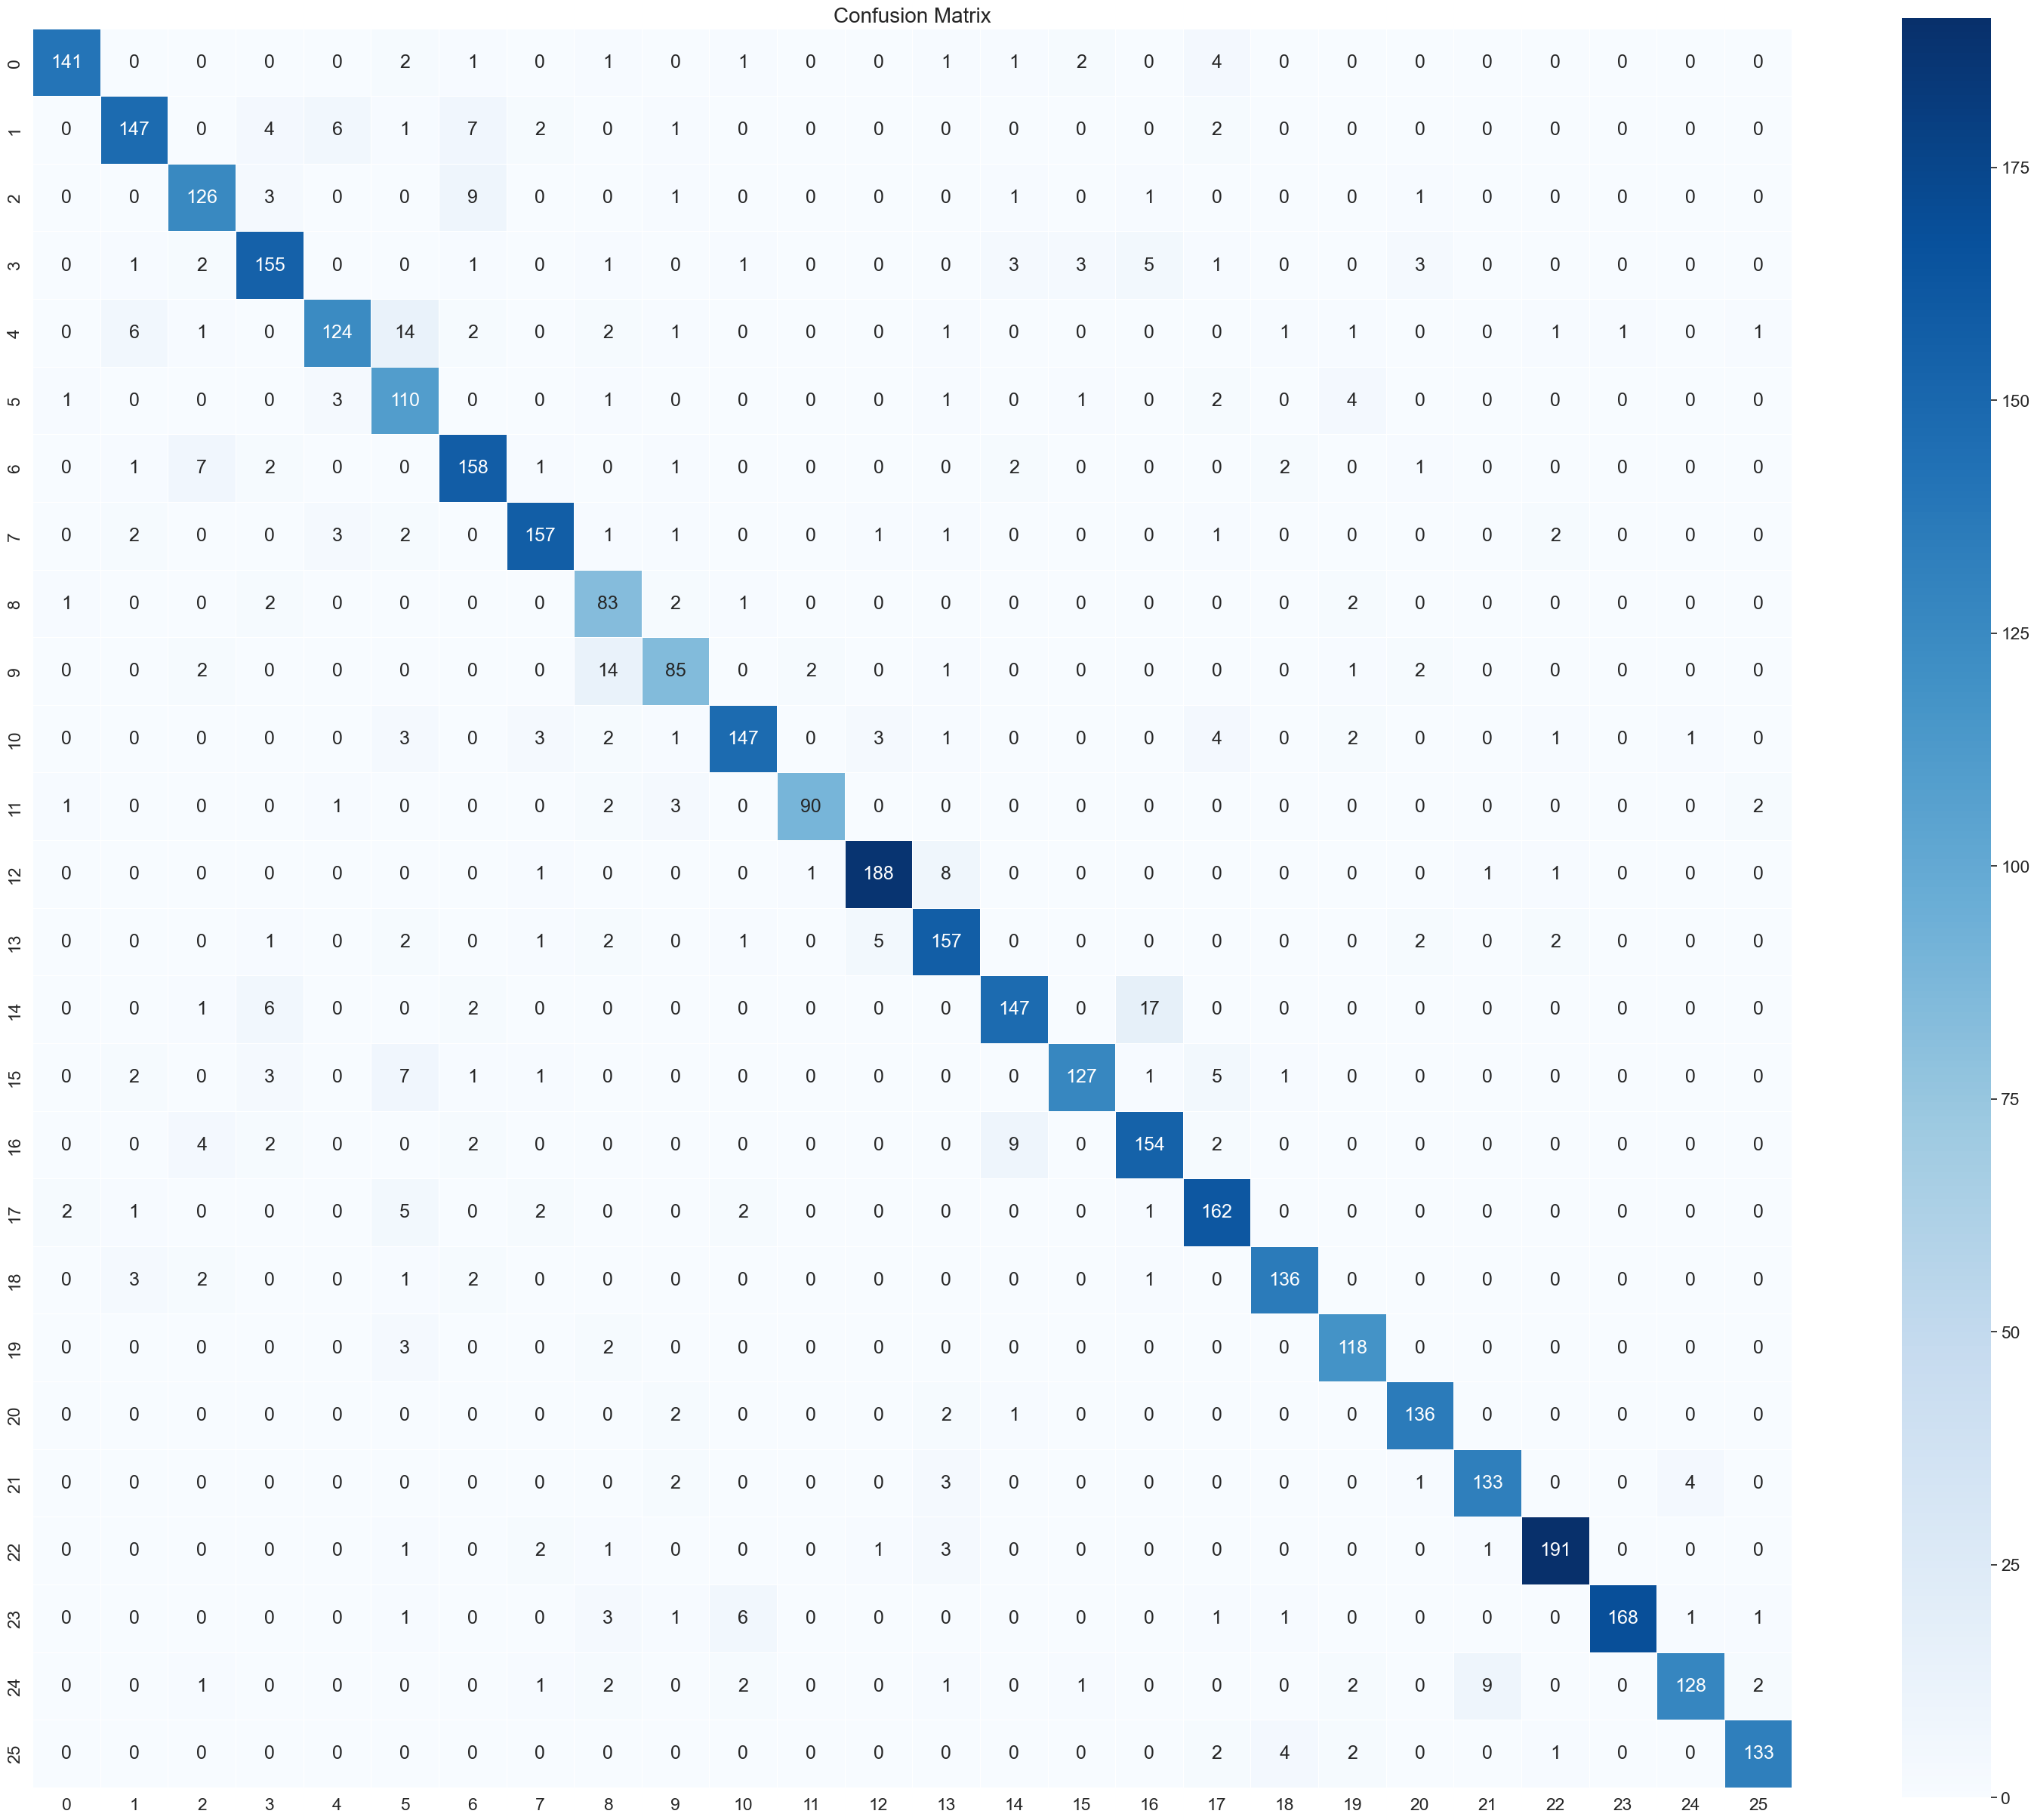

------------------------------------------------------------------------------------------------------------------------------------------------------


In [189]:
# Производим предсказание на валидационной выборке
y_valid_predict = CNN_model.predict(X_valid)
y_valid_predict_classes = np.argmax(y_valid_predict, axis = 1)
y_valid_true = np.argmax(y_valid, axis = 1)




# Заглавие графика
print('\nТепловая карта анализа ошибок классификации:')
print('-' * 150)



# Строим 'confusion_matrix'
cm = metrics.confusion_matrix(y_valid_true, y_valid_predict_classes)

# Задаём размер полотна
plt.rcParams['figure.figsize'] = (30, 30)

# Строим тепловую карту
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    square = True,
    cbar_kws = {'shrink': .8},
    linewidths = 0.5
)

# Настраиваем параметры
plt.title('Confusion Matrix', fontsize = 20)
plt.tight_layout()
    
    
# Выводим график
plt.show()
print('-' * 150)

Посмотрим предсказания на валидационной выборке:


Визуализация букв из изображений:

Количество изображений: 4000
Количество меток: 4000
Количество букв для отображения: 16
Количество столбцов: 4
Количество строк: 4
Размер фигуры: (10, 10)
------------------------------------------------------------------------------------------------------------------------------------------------------


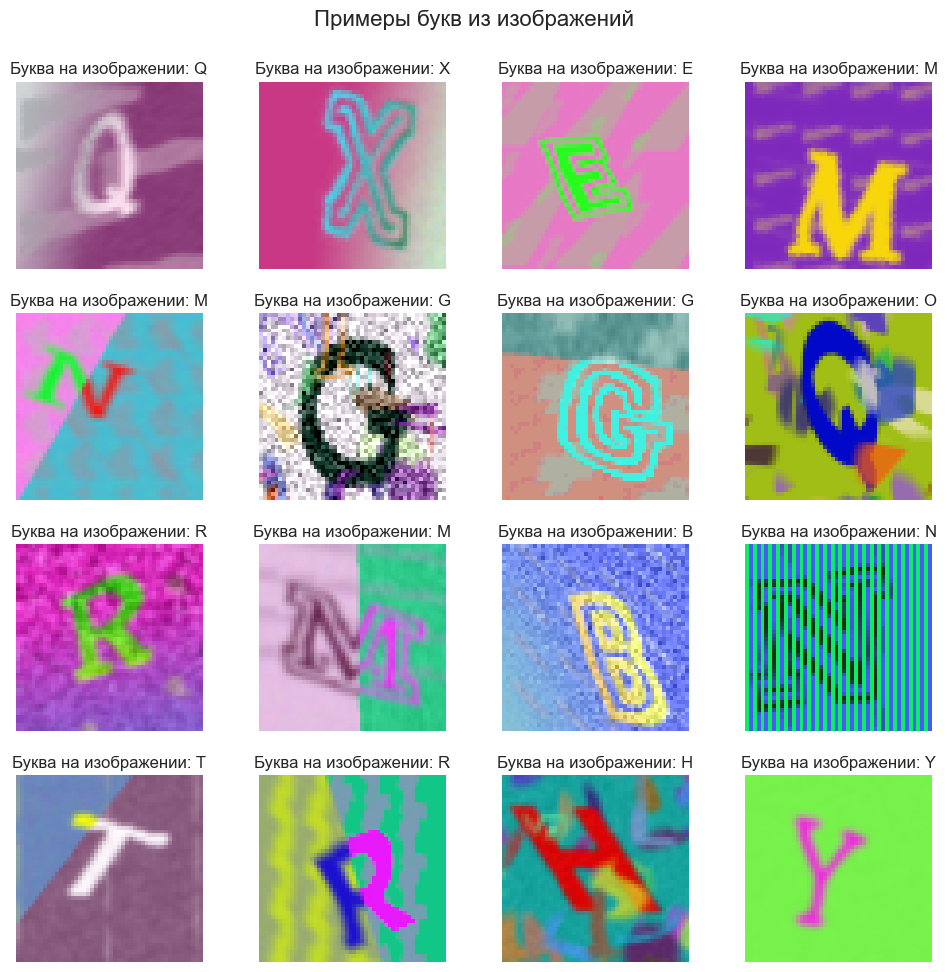

------------------------------------------------------------------------------------------------------------------------------------------------------


In [182]:
# Визуализация предсказанных букв на тестовых изображениях
visualize_letters(
    images = X_valid,
    labels = y_valid_predict_classes,
    figsize = (10, 10) 
)

**Вывод:**

Как видно из полученных результатов, модель в большинстве случаев выдаёт правильные предсказания, хотя иногда ошибается.

#### $3.6$

**Сохраняем полученные результаты.**

Формируем *DataFrame*:

In [184]:
# Создаём индексы
test_ids = np.arange(len(images_sub_data)) 

# Формирование файла с результатами
submission = pd.DataFrame(
    {
    'Id': test_ids,
    'Category': predicted_classes
    }
)



# Выводим информацию по полученным таблицам при помощи функции 'check_data_inf'
check_data_inf(
    data = submission,
    data_name = 'submission df',
    length1 = 40,
    length2 = 25
)

Данные таблицы "submission df" имеют следующую размерность:

Количество строк: 50000;
Количество признаков (столбцов): 2.
----------------------------------------


,Id,Category
0,0,19
1,1,8
2,2,14
3,3,12
4,4,10
...,...,...
49995,49995,5
49996,49996,7
49997,49997,14
49998,49998,3


-------------------------


Сохранение результатов:

In [185]:
# Сохранение результата
submission.to_csv('submission.csv', index = False)
print("Файл 'submission.csv' успешно сохранен!")

Файл 'submission.csv' успешно сохранен!


=============================================================================================================================================